In [ ]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

ACTIONS = ["sleep", "low_sample_rate", "mid_sample_rate", "high_sample_rate"]
NUM_ACTIONS = len(ACTIONS)
N_ACTIVITY, N_BATTERY, N_PROGRESS = 4, 4, 3
NUM_STATES = N_ACTIVITY * N_BATTERY * N_PROGRESS

In [ ]:
class SensorManagementEnv:
    def __init__(self, battery_capacity=9.0, goal_quality=8.0, max_steps=100, energy_weight=0.6, seed=None):
        self.battery_capacity = float(battery_capacity)
        self.goal_quality = float(goal_quality)
        self.max_steps = int(max_steps)
        self.energy_weight = float(energy_weight)
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        # Start each episode with a random observed activity level
        self.activity = self.random_activity()
        self.battery = self.battery_capacity
        self.total_data_quality = 0.0
        self.steps = 0
        return self._get_state()

    def random_activity(self):
        return int (self.rng.integers(0, N_ACTIVITY))

    def step(self, action):
        """Take integer action index 0-3 and return (next_state, reward, done)"""
        if not isinstance(action, (int, np.integer)) or not 0 <= int(action) < NUM_ACTIONS:
            raise ValueError(f"action must be an integer in 0..{NUM_ACTIONS - 1}, got {action!r}")

        action = int(action)
        action_name = ACTIONS[action]
        self.steps += 1
        activity = self.activity

        energy_costs = {
            "sleep": 0.0,
            "low_sample_rate": 0.3,
            "mid_sample_rate": 0.6,
            "high_sample_rate": 1.0,
        }

        quality_table = {
            0: {"sleep": 0.0, "low_sample_rate": 0.0, "mid_sample_rate": 0.0, "high_sample_rate": 0.0},
            1: {"sleep": 0.0, "low_sample_rate": 0.2, "mid_sample_rate": 0.2, "high_sample_rate": 0.2},
            2: {"sleep": 0.0, "low_sample_rate": 0.3, "mid_sample_rate": 0.5, "high_sample_rate": 0.6},
            3: {"sleep": 0.0, "low_sample_rate": 0.4, "mid_sample_rate": 0.7, "high_sample_rate": 1.0},
        }

        energy_cost = energy_costs[action_name]
        data_quality = quality_table[activity][action_name]
        self.battery = max(self.battery - energy_cost, 0.0)
        self.total_data_quality += data_quality
        self.activity = self.random_activity()

        reward = data_quality - self.energy_weight * energy_cost
        done = (
            self.battery <= 0.0
            or self.total_data_quality >= self.goal_quality
            or self.steps >= self.max_steps
        )
        return self._get_state(), reward, done

    def _get_progress_level(self):
        progress_fraction = self.total_data_quality / self.goal_quality
        if progress_fraction < 0.3:
            return 0
        if progress_fraction < 0.7:
            return 1
        return 2

    def _get_battery_level(self):
        if self.battery <= 0.0:
            return 0
        if self.battery <= self.battery_capacity / 3.0:
            return 1
        if self.battery <= 2.0 * self.battery_capacity / 3.0:
            return 2
        return 3

    def _get_state(self):
        return (self.activity, self._get_battery_level(), self._get_progress_level())

In [ ]:
def state_to_index(state):
    activity, battery, progress = state
    return activity * (N_BATTERY * N_PROGRESS) + battery * N_PROGRESS + progress

In [ ]:
print(state_to_index((0,0,0)))
print(state_to_index((3,3,2)))

indices = sorted(
    state_to_index((a,b,p))
    for a in range(N_ACTIVITY)
    for b in range(N_BATTERY)
    for p in range(N_PROGRESS)
)

print(indices == list(range(NUM_STATES)))

0
47
True


In [ ]:
def random_action(state, rng):
    return int(rng.integers(0, NUM_ACTIONS))

def greedy_action(Q, state, rng):
    row = Q[state_to_index(state)]
    ties = np.flatnonzero(row == row.max())
    return int(rng.choice(ties))

def epsilon_greedy_action(Q, state, epsilon, rng):
    if rng.random() < epsilon:
        return random_action(state, rng)
    else:
        return greedy_action(Q, state, rng)

def q_learning_update(Q, state, action, reward, next_state, done, alpha, gamma):
    i = state_to_index(state)
    if done:
        target = reward
    else:
        next_i = state_to_index(next_state)
        target = reward + gamma * np.max(Q[next_i])

    Q[i, action] += alpha * (target - Q[i, action])
    return Q

In [ ]:
def train_q_learning(
    num_episodes = 4000,
    alpha = 0.1,
    gamma = 0.95,
    epsilon = 0.1,
    energy_weight = 0.6,
    seed = 0
):
    rng = np.random.default_rng(seed)
    Q = np.zeros((NUM_STATES, NUM_ACTIONS))
    episode_rewards = []

    for episode in range(num_episodes):
        env = SensorManagementEnv(
            energy_weight = energy_weight,
            seed = rng.integers(1 << 30)
        )
        state = env.reset()
        done = False
        total_reward = 0.0

        while not done:
            action = epsilon_greedy_action(Q, state, epsilon, rng)
            next_state, reward, done = env.step(action)
            q_learning_update(Q, state, action, reward, next_state, done, alpha, gamma)
            total_reward += reward
            state = next_state

        episode_rewards.append(total_reward)

    return Q, episode_rewards

In [ ]:
def simple_action(state, rng=None):
    activity, battery, _ = state
    if battery == 0:
        return 0
    if activity == 3:
        return 2 if battery <= 1 else 3
    if activity == 2:
        if battery <= 1:
            return 1
        if battery <= 2:
            return 2
        return 3
    if activity == 1:
        return 1
    return 0

def greedy_from_Q(Q, state, rng):
    return greedy_action(Q, state, rng)

In [ ]:
def evaluate_policy(action_fn, num_episode = 500, energy_weight = 0.6, seed = 123):
    rng = np.random.default_rng(seed)
    returns, lengths, successes = [], [], []

    for episode in range(num_episode):
        env = SensorManagementEnv(
            energy_weight = energy_weight,
            seed = rng.integers(1 << 30)
        )
        state = env.reset()
        done = False
        total_reward = 0.0
        length = 0

        while not done:
            action = action_fn(state, rng)
            state, reward, done = env.step(action)
            total_reward += reward
            length += 1

        returns.append(total_reward)
        lengths.append(length)
        successes.append(env.total_data_quality >= env.goal_quality)

    return {
        "average_return": float(np.mean(returns)),
        "average_length": float(np.mean(lengths)),
        "success_rate": float(np.mean(successes))
    }

In [ ]:
if __name__ == "__main__":
    # Self-check for Task 1.
    print("state_to_index((0, 0, 0)) =", state_to_index((0, 0, 0)), "(should be 0)")
    print("state_to_index((3, 3, 2)) =", state_to_index((3, 3, 2)), "(should be 47)")

    Q, rewards = train_q_learning()
    print("first-100 mean reward:", round(float(np.mean(rewards[:100])), 3))
    print("last-100 mean reward: ", round(float(np.mean(rewards[-100:])), 3))

    results = [
        ("random", evaluate_policy(random_action)),
        ("simple", evaluate_policy(simple_action)),
        ("learned Q", evaluate_policy(lambda s, r: greedy_from_Q(Q, s, r))),
    ]
    print("\n{:<18}{:>12}{:>12}{:>10}".format("policy", "avg_reward", "avg_len", "success"))
    for name, result in results:
        print("{:<18}{:>12.3f}{:>12.1f}{:>10.2f}".format(
            name,
            result["average_return"],
            result["average_length"],
            result["success_rate"],
        ))

state_to_index((0, 0, 0)) = 0 (should be 0)
state_to_index((3, 3, 2)) = 47 (should be 47)
first-100 mean reward: 2.414
last-100 mean reward:  2.969

policy              avg_reward     avg_len   success
random                  -0.486        20.1      0.00
simple                   2.593        20.9      0.70
learned Q                3.667        34.6      1.00


In [ ]:
Q, rewards = train_q_learning()
window = 100
smoothed = np.convolve(rewards, np.ones(window) / window, mode="valid")
plt.figure()
plt.plot(smoothed)
plt.xlabel("episode")
plt.ylabel("undiscounted episode reward (100-episode moving average)")
plt.title("Q-learning on adaptive sensor management")
plt.tight_layout()
plt.savefig("week3_curve.png", dpi=150)

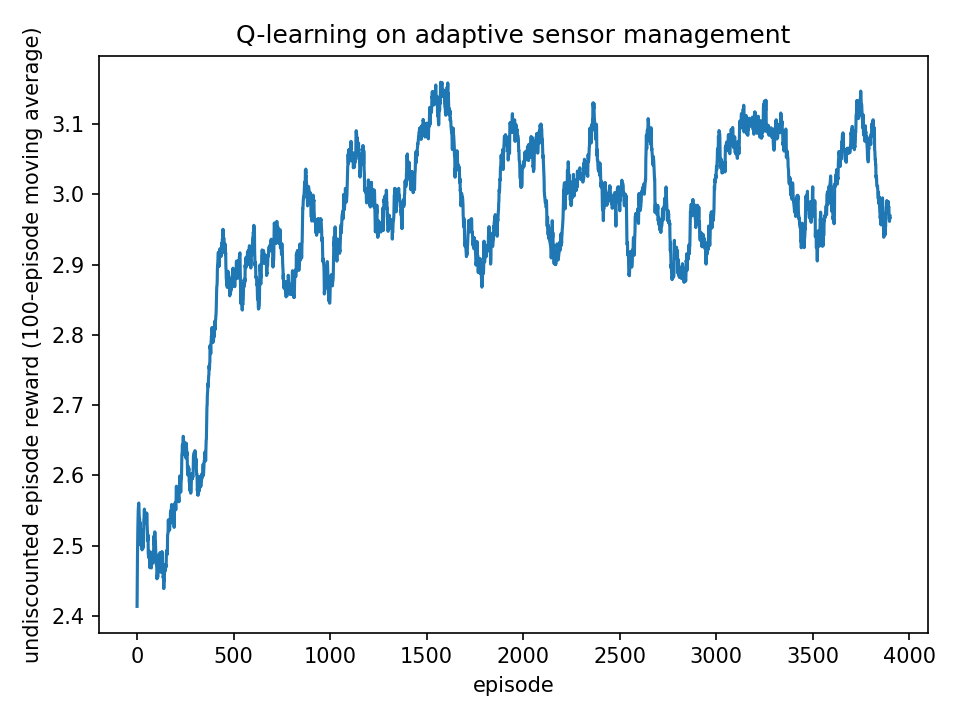

In [ ]:
from IPython.display import Image
Image('week3_curve.png')